Episode 1: Total Reward = -1110
Episode 2: Total Reward = -974
Episode 3: Total Reward = -645
Episode 4: Total Reward = -592
Episode 5: Total Reward = -524
Episode 6: Total Reward = -603
Episode 7: Total Reward = -692
Episode 8: Total Reward = -467
Episode 9: Total Reward = -607
Episode 10: Total Reward = -477
Episode 11: Total Reward = -133
Episode 12: Total Reward = -509
Episode 13: Total Reward = -249
Episode 14: Total Reward = -512
Episode 15: Total Reward = -442
Episode 16: Total Reward = -465
Episode 17: Total Reward = -419
Episode 18: Total Reward = -755
Episode 19: Total Reward = -666
Episode 20: Total Reward = -404
Episode 21: Total Reward = -421
Episode 22: Total Reward = -670
Episode 23: Total Reward = -509
Episode 24: Total Reward = -457
Episode 25: Total Reward = -665
Episode 26: Total Reward = -540
Episode 27: Total Reward = -299
Episode 28: Total Reward = -579
Episode 29: Total Reward = -362
Episode 30: Total Reward = -307
Episode 31: Total Reward = -559
Episode 32: Tota

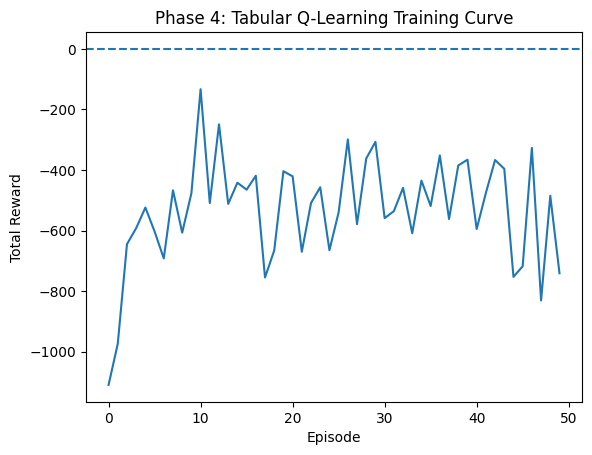

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Path setup
# -----------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv

# -----------------------
# Load data
# -----------------------
data = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "synthetic_hospital_data.csv"))

# -----------------------
# Discretization bins
# -----------------------
arrival_bins = np.linspace(0, 480, 6)
slot_bins = np.linspace(0, 480, 6)
no_show_bins = np.linspace(0, 1, 6)
icu_bins = np.linspace(0, 1, 6)

def discretize_state(state):
    arrival, slot, priority, no_show, icu_ratio = state

    a = np.digitize(arrival, arrival_bins)
    s = np.digitize(slot, slot_bins)
    n = np.digitize(no_show, no_show_bins)
    i = np.digitize(icu_ratio, icu_bins)

    return (a, s, int(priority), n, i)

# -----------------------
# Q-table
# -----------------------
Q = {}
actions = [0, 1]

def get_Q(state):
    if state not in Q:
        Q[state] = {a: 0.0 for a in actions}
    return Q[state]

# -----------------------
# Hyperparameters
# -----------------------
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 50

episode_rewards = []

# -----------------------
# Training loop
# -----------------------
for ep in range(episodes):

    env = HospitalEnv(data)
    state = discretize_state(env.reset())
    done = False
    total_reward = 0

    while not done:

        # ε-greedy
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = max(get_Q(state), key=get_Q(state).get)

        next_state, reward, done = env.step(action)
        total_reward += reward

        if not done:
            next_state = discretize_state(next_state)
            best_next = max(get_Q(next_state).values())
        else:
            best_next = 0

        # Q update
        get_Q(state)[action] += alpha * (
            reward + gamma * best_next - get_Q(state)[action]
        )

        state = next_state

    episode_rewards.append(total_reward)
    print(f"Episode {ep+1}: Total Reward = {total_reward}")

print("\nTraining completed.")

# -----------------------
# Plot learning curve
# -----------------------
plt.figure()
plt.plot(episode_rewards)
plt.axhline(0, linestyle="--")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Phase 4: Tabular Q-Learning Training Curve")
plt.show()
